# Installation

```python
pip install transformers # not needed in Colab
```

In [ ]:
import transformers

# Your First Pipeline Abstraction

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification")
result = classifier("This is an amazing course!")
print(result)

Before we move ahead, let's understand the what is printed in the console.

* **Default Model Loaded**: Since we didn't specify a particular model, so the system defaulted to loading **`distilbert-base-uncased-finetuned-sst-2-english`**. This is a popular model for sentiment analysis.


  * **distilbert**: Denotes the foundational neural network architecture.
  * **base**: Indicates the hyperparameter scale. In this context, it means only 6 transformer encoder layers were used compared to standard BERT's 12 encoder layers.
  * **uncased**: All input text is turned to lower case before executing the WordPiece tokenization algorithm.
  * **english**: The corpus consists strictly of English text.
  * **finetuned-sst-2**: Identifies the specific downstream dataset used for the fine-tuning phase. SST-2 refers to the Stanford Sentiment Treebank version 2. It is a standard NLP benchmark dataset consisting of sentences from movie reviews, structured strictly for binary classification (mapping text to either a positive or negative sentiment label).
* **Authentication Warning**: We're seeing a `UserWarning` because we haven't authenticated with Hugging Face using a secret token (`HF_TOKEN`). While not required for public models, it's recommended practice, especially for private models or for tracking usage.
* **Model Download**: The green progress bars show the successful download of the model's components. This includes the model's architecture (`config.json`), its trained weights (`model.safetensors`), and the tokenizer files (`tokenizer_config.json`, `vocab.txt`) which prepare text for the model.
* **Hardware Allocation**: The final line, `Device set to use cpu`, indicates that the model will run on the Central Processing Unit (CPU) of the machine. For larger models, a GPU or TPU would provide a significant speed-up.
* **Model Prediciton**: The output is a list containing a dictionary with the predicted label and its corresponding confidence score.


## Natural Language Processing (NLP) Pipelines

### Text Classification
This is often the "hello, world" of transformers. The pipeline classifies a piece of text into a set of predefined categories. The most common use is sentiment analysis, which determines if a text is positive, negative, or neutral.

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification")
result = classifier(["This is not okay thing to do.", "This is amazing!!"])
print(result)

### Text Generation

This pipeline takes a starting prompt and generates subsequent text, making it useful for creative writing, code completion, or chatbot responses.

In [ ]:
from transformers import pipeline
generator = pipeline("text-generation")
result = generator("In a world where AI is king,")
print(result)

### Token Classification (Named Entity Recognition - NER)
This pipeline, identified by "ner" or "token-classification", classifies each token in a sentence into a category, such as a person (`PER`), organization (`ORG`), or location (`LOC`).

In [ ]:
from transformers import pipeline
ner_pipeline = pipeline("ner")
result = ner_pipeline("Hugging Face Inc. is a company based in New York City.")
print(result)

In [ ]:
del classifier
del generator
del ner_pipeline

import gc
gc.collect()

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

### Fill-Mask
Given a text with a masked token (e.g., <mask>), this pipeline predicts the most likely words to fill that mask.

In [ ]:
from transformers import pipeline
unmasker = pipeline("fill-mask")
result = unmasker("The capital of [MASK] is Paris.")
print(result)

### Zero-Shot Classification
This is one of the most powerful and flexible pipelines. It allows you to classify text using any set of candidate labels you provide on the fly, without the model having been explicitly trained on those specific labels.

In [ ]:
from transformers import pipeline
zero_shot_classifier = pipeline("zero-shot-classification")
sequence = "Who are you voting for in 2026?"
candidate_labels = ["politics", "business", "technology"]
result = zero_shot_classifier(sequence, candidate_labels)
print(result)

## Computer Vision Pipelines

The pipeline abstraction extends seamlessly to modalities beyond text, demonstrating its versatility.


#### Code to download cat image - IGNORE

In [ ]:
! pip install requests

In [ ]:
import requests
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'

# The fix: Mimicking a real web browser to bypass the 403 block
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print("Downloading image...")
image_response = requests.get(image_url, headers=headers)
image_response.raise_for_status()

# Save the image
save_path = "lenna.png"
with open(save_path, 'wb') as f:
    f.write(image_response.content)

print(f"Success! Image saved as '{save_path}'\n")

# --- Displaying the Image in Colab ---
img = mpimg.imread(save_path)
plt.imshow(img)
plt.title("Test Image for Computer Vision Pipeline Abstraction Tasks")
plt.axis('off')
plt.show()

### Image Classification
Assigns a label to an entire image from a set of predefined classes.

In [ ]:
from transformers import pipeline
image_classifier = pipeline("image-classification")
result = image_classifier("/content/lenna.png")
print(result[0])

### Object Detection
Identifies multiple objects within an image and returns their class labels along with bounding box coordinates.

In [ ]:
from transformers import pipeline
object_detector = pipeline("object-detection", use_fast=False)
result = object_detector("/content/lenna.png")
print(result[0])

In [ ]:
from transformers import pipeline
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Load the image using PIL so we can draw on it
image = Image.open("/content/lenna.png")
draw = ImageDraw.Draw(image)


# Grab the very first detection in the list
detection = result[0]

box = detection['box']
label = detection['label']
score = detection['score']

# Calculate percentage score string with one decimal place
score_percent_str = f"{score * 100:.1f}%"

# Extract coordinates
xmin = box['xmin']
ymin = box['ymin']
xmax = box['xmax']
ymax = box['ymax']

# We'll just use red for this single box
color = (29, 255, 59)

# Draw the rectangle
draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)

# Add the label and confidence score string
text = f"{label} ({score_percent_str})"
draw.text((xmin, ymin - 15), text, fill=color)

# Display the modified image in Colab
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Object Detection Result (Top Detection Only)")
plt.axis('off')
plt.show()

### Image Segmentation
Classifies each pixel in an image into a category.

In [ ]:
from transformers import pipeline
object_detector = pipeline("image-segmentation", model = "facebook/detr-resnet-50-panoptic")
result = object_detector("/content/lenna.png")
print(result)

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

for item in result:
    if 'mask' in item and isinstance(item['mask'], Image.Image):
        if item.get('label') == 'LABEL_199':
          item['label'] = 'background'
        print(f"Label: {item.get('label', 'N/A')}, Score: {item.get('score', 'N/A'):.4f}")
        plt.imshow(item['mask'])
        plt.axis('off')
        plt.show()

# Pipeline Tasks Overview

|Modality       |Task Identifier             |Task Aliases      |Description                                        |Expected Input(s)                    |Sample Output Structure                                      |
|---------------|----------------------------|------------------|---------------------------------------------------|-------------------------------------|-------------------------------------------------------------|
|NLP            |text-classification         |sentiment-analysis|Classifies a sequence into a set of labels.        |str or List[str]                     |[{'label': str, 'score': float}]                             |
|NLP            |token-classification        |ner               |Classifies each token in a sequence.               |str or List[str]                     |[{'entity': str, 'score': float, 'word': str,...}]           |
|NLP            |fill-mask                   |                  |Predicts a masked token in a sequence.             |str or List[str] with a mask token   |[{'score': float, 'token_str': str,...}]                     |
|NLP            |text-generation             |                  |Generates text following a prompt.                 |str or List[str]                     |[{'generated_text': str}]                                    |
|NLP            |zero-shot-classification    |                  |Classifies a sequence using arbitrary labels.      |str, candidate_labels=List[str]      |{'sequence': str, 'labels': List[str], 'scores': List[float]}|
|NLP            |feature-extraction          |                  |Converts text into a dense vector representation.  |str or List[str]                     |List[List[float]] or np.ndarray                              |
|Computer Vision|image-classification        |                  |Classifies an entire image.                        |Image path, URL, or PIL.Image        |[{'score': float, 'label': str}]                             |
|Computer Vision|object-detection            |                  |Detects objects with bounding boxes in an image.   |Image path, URL, or PIL.Image        |                                                           |
|Computer Vision|image-segmentation          |                  |Classifies each pixel in an image into a category. |Image path, URL, or PIL.Image        |[{'score': float, 'label': str, 'mask': PIL.Image}]          |
|Computer Vision|image-to-text               |                  |Generates a caption for an image.                  |Image path, URL, or PIL.Image        |[{'generated_text': str}]                                    |
|Audio          |audio-classification        |                  |Classifies an audio snippet.                       |Audio path, URL, or raw waveform     |[{'score': float, 'label': str}]                             |
|Audio          |automatic-speech-recognition|                  |Transcribes speech from an audio file to text.     |Audio path, URL, or raw waveform     |{'text': str}                                                |
|Audio          |text-to-speech              |                  |Converts text into a spoken audio waveform.        |str                                  |np.ndarray (waveform), int (sampling rate)                   |
|Multimodal     |document-question-answering |                  |Answers a question based on an image of a document.|image, question                      |[{'score': float, 'answer': str,...}]                        |
|Multimodal     |visual-question-answering   |                  |Answers a question based on a general image.       |image, question                      |[{'score': float, 'answer': str}]                            |


# Beyond the Defaults

## Generic Parameters

### `model`


In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation", model="openai-community/gpt2")
prompt = "The secret to a happy life is"
output = generator(prompt)
print(output[0]['generated_text'])

### `tokenizer`

In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation", model="openai-community/gpt2", tokenizer='openai-community/gpt2')
prompt = "The secret to a happy life is"
output = generator(prompt)
print(output[0]['generated_text'])

### `device`
Maps the model allocation to a specific hardware index (e.g., `-1` for CPU, `0` for CUDA:0).


In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation", model="gpt2", tokenizer='gpt2', device=0)
prompt = "The secret to a happy life is"
output = generator(prompt)
print(output[0]['generated_text'])

### `num_workers`
Number of subprocess threads allocated for asynchronous data loading operations.

In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation", num_workers=2)
prompt = "The secret to a happy life is"
output = generator(prompt)
print(output[0]['generated_text'])

## Text Generation

In [ ]:
from transformers import pipeline

generator = pipeline(task="text-generation", model="gpt2")
prompt = "The secret to a happy life is"

### `max_length`
Hard limit on the total sequence length (prompt + generated tokens).

In [ ]:
output = generator(prompt, max_length=20)
print(output['generated_text'])

You will see the following warning:

```
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence.
```

### `max_new_tokens`
Maximum number of strictly generated tokens, independent of prompt length. (Highly recommended over `max_length`).

In [ ]:
output = generator(prompt, max_new_tokens=10)
print(output[0]['generated_text'])

You are remove all of the transformer logs using `transformers.logging.set_verbosity_error()`.

In [ ]:
import transformers
transformers.logging.set_verbosity_error() # This will remove all logs for all following executions

### `min_length`
Minimum length constraint for the total sequence.

In [ ]:
output = generator(prompt, min_length=50)
print(output[0]['generated_text'])

### `min_new_tokens`
Minimum length constraint strictly for the generated part of the sequence output.

In [ ]:
output = generator(prompt, min_new_tokens=30)
print(output[0]['generated_text'])

### `do_sample`
Toggles multinomial sampling. Setting this to `True` abandons deterministic greedy decoding.

In simple English, setting this to `True` tells the AI to stop being so predictable and start rolling some dice - which means it may not make sense always.

In [ ]:
output = generator(prompt, do_sample=True)
print(output[0]['generated_text'])

### `temperature`
Scales the logits to manipulate randomness. (Requires `do_sample=True`). Low values (<1.0) make it safer; high values (>1.0) make it more random.

In [ ]:
output = generator(prompt, do_sample=True, temperature=1.8)
print(output[0]['generated_text'])

### `top_k`
Restricts the sampling pool to the k most probable next tokens. (Requires do_sample=True).

In [ ]:
output = generator(prompt, do_sample=True, top_k=4)
print(output[0]['generated_text'])

### `top_p`
You set a percentage budget, like `top_p=0.90` (90%). The AI keeps adding words to the pool until their combined chances equal 90%.

In [ ]:
output = generator(prompt, do_sample=True, top_p=0.92)
print(output[0]['generated_text'])

In [ ]:
output = generator(prompt, do_sample=True, top_p=0.000002)
print(output[0]['generated_text'])

#### Note on `top_p` and `top_k`
When the AI is generating text, it looks at its entire vocabulary (thousands of words) and assigns a percentage chance to every single word being the next correct word. Most of those words are terrible choices (near 0%), and a few are great choices.

`top_k` and `top_p` are two different ways of taking a pair of scissors and cutting off the bad choices before the AI rolls the dice to pick the winner.

- **OPINION:** In my personal experience, they are really similar, AND they are similarly poor parameters to control your AI.

### `repetition_penalty`
Penalty multiplier applied to previously generated tokens to prevent looping. Values > 1.0 penalize repetition.

In [ ]:
output = generator(prompt, repetition_penalty=1.2)
print(output[0]['generated_text'])

### `num_return_sequences`
The quantity of independent sequence outputs to compute. (Requires `do_sample=True`).

In [ ]:
outputs = generator(prompt, do_sample=True, num_return_sequences=3)

for i, out in enumerate(outputs):
    print(f"Output {i+1}: {out['generated_text']}")
    print("=" * 30)
    print("=" * 30)
    print("=" * 30)

### `eos_token_id` & `pad_token_id`
Overrides the End-Of-Sequence and Padding token IDs. Often used to suppress warnings by explicitly setting the pad token to the eos token.

In [ ]:
output = generator(
    prompt,
    eos_token_id=generator.tokenizer.eos_token_id,
    pad_token_id=generator.tokenizer.eos_token_id
)
print(output[0]['generated_text'])

While `text-generation` has the largest suite of parameters, the Hugging Face `pipeline` abstraction provides task-specific parameters for other NLP tasks.



### Text Classification (Sentiment Analysis)

This pipeline assigns labels to a given text. By default, it only returns the single most likely label.

| Parameter | Description | Output Impact |
| --- | --- | --- |
| **`function_to_apply`** | The mathematical function applied to the model's raw logits. | Options are `"default"`, `"softmax"`, `"sigmoid"`, or `"none"`. `"none"` outputs raw, unscaled tensor values, which is useful for custom downstream math. |

---

### Token Classification (Named Entity Recognition - NER)

This pipeline tags individual tokens (words or subwords) within a sentence (e.g., tagging people, locations, organizations).

| Parameter | Description | Output Impact |
| --- | --- | --- |
| **`aggregation_strategy`** | How to group sub-tokens back into full words. | Subwords (like "New" and "York") might get separate tags. `"simple"` or `"first"` merges them into a single "New York" entity, drastically cleaning up the output list. |
| **`ignore_labels`** | A list of classification labels to exclude from the results. | By default, the `O` (Outside/No Entity) label is ignored to save space. You can override this to see the classification of *every* word, or ban specific entity types like `"B-ORG"`. |

---

### Question Answering (Extractive QA)

This pipeline extracts an answer from a provided `context` paragraph based on a `question`.

| Parameter | Description | Output Impact |
| --- | --- | --- |
| **`max_answer_len`** | The maximum character length of the extracted answer. | Prevents the model from returning massive, paragraph-long answers when you only want a concise phrase or name. |
| **`handle_impossible_answer`** | Allows the model to output an empty string if no answer is present. | If `False`, the model is forced to guess blindly. If `True`, and the context lacks the info, it will return an empty answer with a high confidence score of being "impossible." |

---

### Zero-Shot Classification

This pipeline classifies text into custom labels that the model wasn't explicitly trained on, using Natural Language Inference (NLI).

| Parameter | Description | Output Impact |
| --- | --- | --- |
| **`candidate_labels`** | The list of custom categories you want the text sorted into. | Directly dictates the output structure. The model will return these exact strings along with their calculated probabilities. |
| **`multi_label`** | Determines if the probabilities across all labels must sum to 100%. | If `True`, each label is evaluated independently (e.g., a text can be 90% "Space" and 85% "Science"). If `False`, they compete (e.g., 60% "Space", 40% "Science"). |



# A Simple Proof-of-Concept

In [ ]:
import torch
from transformers import pipeline

# 1. Setup Device
device = 0 if torch.cuda.is_available() else -1
print("Initializing pipelines (this may take a moment to download models)...\n")

# Pipeline A: Zero-Shot Classification (Used for Tasks 1 & 3)
zero_shot_pipe = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)

# Pipeline B: Sentiment Analysis (Used for Task 2)
sentiment_pipe = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

# Pipeline C: Text Generation (Used for Task 4)
# We use a fast, instruction-following model to draft the email
text_gen_pipe = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-135M-Instruct", device=device)

# 2. Define the Customer Data and Taxonomies
customer_messages = [
    "I was charged twice for my subscription this month. I need a refund immediately!",
    "The new dashboard update is fantastic, my team loves the dark mode feature.",
    "I can't seem to reset my password. Every time I click the link, it says expired.",
    "Do you offer enterprise pricing for teams larger than 50 people?",
    "Your app keeps crashing every time I try to upload a PDF. This is completely unacceptable and blocking my work.",
    "How do I completely delete my account and all associated data?"
]

departments = ["Billing & Finance", "Technical Support", "Sales", "Product Feedback"]
topics = ["Refund Request", "Bug/Crash", "Account Management", "Feature Praise", "Pricing Inquiry", "Data Privacy"]

# 3. Process the Data Flow
for i, message in enumerate(customer_messages, 1):
    print(f"{'='*50}")
    print(f"MESSAGE {i}: \"{message}\"")

    # Task 1: Department Routing
    dept_result = zero_shot_pipe(message, candidate_labels=departments)
    assigned_dept = dept_result['labels'][0]

    # Task 2: Sentiment Extraction
    sentiment_result = sentiment_pipe(message)[0]
    sentiment_label = sentiment_result['label']

    # Task 3: Topic Classification
    topic_result = zero_shot_pipe(message, candidate_labels=topics)
    assigned_topic = topic_result['labels'][0]

    # Task 4: Generate Recommended Response
    # We construct a prompt that gives the LLM context about the routing and sentiment
    messages = [
        {
            "role": "system",
            "content": f"You are a helpful customer support agent for the {assigned_dept} department. Write a brief, professional, and empathetic 2-sentence response."
        },
        {
            "role": "user",
            "content": message
        }
    ]

    # Passing a list of dicts triggers the chat template automatically
    gen_out = text_gen_pipe(
        messages,
        max_new_tokens=50,
        temperature=0.7,
        clean_up_tokenization_spaces=False # This silences the tokenizer warning in your logs
    )

    # The pipeline returns the full conversation history; we extract the last message (the assistant's reply)
    recommended_reply = gen_out[0]["generated_text"][-1]["content"].strip()

    # Output the structured metadata
    print("-" * 50)
    print(f"► ROUTING:  {assigned_dept} (Confidence: {dept_result['scores'][0]:.2f})")
    print(f"► TOPIC:    {assigned_topic} (Confidence: {topic_result['scores'][0]:.2f})")
    print(f"► SENTIMENT:{sentiment_label} (Confidence: {sentiment_result['score']:.2f})")
    print(f"► DRAFT REPLY:\n  {recommended_reply}\n")

# Variations of Transformers

## BERT: BiDirectional Encoder Representations from Transformers


In [ ]:
from transformers import pipeline
unmasker = pipeline("fill-mask", model="bert-base-uncased")
result = unmasker("The capital of [MASK] is Paris.")
print(result)

## DistilBERT

In [ ]:
from transformers import pipeline
unmasker = pipeline("fill-mask", model="distilbert-base-uncased")
result = unmasker("The capital of [MASK] is Paris.")
print(result)

## RoBERTa: Robustly Optimized BERT Pretraining Approach

In [ ]:
from transformers import pipeline
unmasker = pipeline("fill-mask", model="roberta-base")
result = unmasker("The capital of <mask> is Paris.")
print(result)

## GPT2: Generative Pre-trained Transformer 2

In [ ]:
from transformers import pipeline
generator = pipeline("text-generation", model="gpt2")
result = generator("In a world where AI is king,")
print(result)

## BART: Bidirectional and Auto-Regressive Transformer


In [ ]:
from transformers import pipeline

# Initialize the zero-shot classification pipeline
classifier = pipeline(task="zero-shot-classification", model="facebook/bart-large")

sequence_to_classify = "The query execution time has degraded by 40% after the index rebuild."
candidate_labels = ["network infrastructure", "database optimization", "front-end rendering", "security breach"]

# Execute inference
result = classifier(
    sequence_to_classify,
    candidate_labels,
    multi_label=False # Normalizes probabilities across all candidate labels to sum to 1
)

print(result)

# The AutoTokenizer Family

In [ ]:
from transformers import AutoTokenizer

# Load the fast version of the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("openai/gpt-oss-20b")

print(type(tokenizer))

Notice the "Fast" at the end of the tokenizer type. The Fast AutoTokenizers are built in Rust, and are the default version now.



Older versions of AutoTokenizers are also available. These are implemented in Python, and so slow that they are literally called "Slow" Tokenizers.


Although not recommended, you can explicitly request a slow tokenizer by setting the `use_fast=False` parameter. This may be required for legacy code.

In [ ]:
from transformers import AutoTokenizer

# Load the slow version of the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=False)

print(type(tokenizer))

In [ ]:
help(tokenizer)

In [ ]:
from transformers import AutoTokenizer

model = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model)

raw_inputs = [
    "I have been waiting for this course my whole life",
    "I hate this so much!",
]
input_ids = tokenizer(raw_inputs, padding=True, return_tensors="pt")
print(input_ids)



**`model = "distilbert-base-uncased-finetuned-sst-2-english"`**

This line defines the pre-trained model we want to use. Let's decode this name:

  * **`distilbert-base-uncased`**: This is the base model, a smaller, faster version of BERT-base. "Uncased" means all text was converted to lowercase during its training.
  * **`finetuned-sst-2-english`**: This indicates the model was further trained (fine-tuned) on the **SST-2 (Stanford Sentiment Treebank v2)** dataset, which is a collection of English movie reviews labeled with positive or negative sentiment. This fine-tuning makes the model particularly good at sentiment analysis.



**`input_ids = tokenizer(...)`**
This is the core step where the tokenizer processes the `raw_inputs`.

* **`tokenizer(raw_inputs, ...)`**: The tokenizer takes our list of sentences and converts each one into a sequence of numbers (IDs). Each ID corresponds to a specific "token" (a word or part of a word) in the tokenizer's vocabulary.
* **`padding=True`**: Since sentences have different lengths, this option pads the shorter sentence with a special padding token ID (`0`) to make both sequences the same length. This is necessary for processing them together as a batch.
* **`return_tensors="pt"`**: This specifies that the output should be a PyTorch tensor (`pt`), which is the standard data structure used in the PyTorch deep learning framework.




**The Output Explained:**


```
{
'input_ids': tensor([
  [ 101, 1045, 1005, 2310, 2042, 3403, 2023, 2607, 2026, 2878, 2166, 1012,  102],
  [ 101, 1045, 5223, 2023, 2061, 2172,  999,  102,    0,    0,    0,    0,    0]
]),
'attention_mask': tensor([
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
])
}
```

* **`input_ids`**: This tensor contains the numerical representations of your sentences.

    * `[101]` is the ID for the special `[CLS]` (classification) token, which is added to the beginning of every sequence.
    * `[102]` is the ID for the special `[SEP]` (separator) token, marking the end of a sentence.
    * Notice the `0`s at the end of the second sequence. These are the padding tokens added to make its length equal to the first sequence's length.

* **`attention_mask`**: This tells the model which tokens to pay attention to.

    * It contains a `1` for every real token (including `[CLS]` and `[SEP]`).
    * It contains a `0` for every padding token. This ensures the model ignores the padding and doesn't let it influence the final prediction.


# The AutoModel Family

## AutoModel

The base `AutoModel` is used to load the core architecture of a pretrained model, which gives you the hidden states (or last hidden state) of the model.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

model_name = "google-bert/bert-base-uncased"

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(type(tokenizer))
print("="*30)

model = AutoModel.from_pretrained(model_name)
print(type(model))
print("="*30)

# Prepare the input text
raw_text = "This is a sample sentence."
input_ids = tokenizer(raw_text, return_tensors="pt")

# Get the model's last hidden state and not update it
with torch.no_grad():
  logits = model(**input_ids)


print(f"Logits: {logits}")

## AutoModelForSequenceClassification

This variant is designed for text classification tasks. It includes a classification head on top of the base model.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")
print(type(tokenizer), type(model))
print("="*50)

# Prepare the input text
text = "Hugging Face is doing a great job."
input_ids = tokenizer(text, return_tensors="pt")

# Get the classification logits
with torch.no_grad():
    logits = model(**input_ids).logits


print(logits)
# Get the predicted class
predicted_class_id = torch.argmax(logits, dim=1).item()
print(f"Predicted class ID: {predicted_class_id}")
print(f"Predicted label: {model.config.id2label[predicted_class_id]}")

## AutoModelForCausalLM

This is used for causal language modeling, which is essentially text generation. It has a language modeling head that predicts the next token in a sequence.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load the tokenizer and model for causal language modeling
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")

# Prepare the input text
text = "The quick brown fox jumps over the"
input_ids = tokenizer(text, return_tensors="pt")

print(input_ids)
print("="*30)

with torch.no_grad():
  logits = model.generate(**input_ids, max_length=15)

print(logits)
print("="*30)
# Generate text
generated_text = tokenizer.decode(logits[0], skip_special_tokens=True)

print(generated_text)

## AutoModelForQuestionAnswering

This variant is designed for extractive question answering, where the model finds the answer to a question within a given context.

In [ ]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("deepset/roberta-base-squad2")
model = AutoModelForQuestionAnswering.from_pretrained("deepset/roberta-base-squad2")


# Define the question and context
context = "France is a country in Western Europe. Its capital and largest city is Paris."
question = "What is the capital of France?"

# Prepare the inputs
input_ids = tokenizer(question, context, return_tensors="pt")
print(input_ids)

# Get the start and end logits for the answer
with torch.no_grad():
    logits = model(**input_ids)

print(logits)
# Find the tokens with the highest start and end scores
answer_start_index = torch.argmax(logits.start_logits)
answer_end_index = torch.argmax(logits.end_logits) + 1
print(answer_start_index, answer_end_index)

# Convert the token indices to the answer string
predict_answer_tokens = input_ids.input_ids[0, answer_start_index : answer_end_index]
answer = tokenizer.decode(predict_answer_tokens)

print(f"Answer: {answer}")

## Some parameters to be aware of

|Parameter                    |Description                                                                                                                             |Example                            |
|-----------------------------|----------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------|
|pretrained_model_name_or_path|The identifier for the model. Can be a model ID from the Hub or a local path.                                                           |"google-bert/bert-base-uncased"    |
|cache_dir                    |Path to a directory to cache downloaded models, overriding the default.                                                                 |cache_dir="/path/to/my/cache/"     |
|torch_dtype                  |Overrides the default data type to load the model with a different precision (e.g., torch.float16). Essential for reducing memory usage.|torch_dtype=torch.bfloat16         |
|device_map                   |Specifies how to distribute model layers across devices (GPUs, CPU, disk). Set to "auto" for automatic distribution.                    |device_map="auto"                  |
|max_memory                   |A dictionary specifying the max memory to allocate on each device when using device_map="auto".                                         |max_memory={0: "12GiB", 1: "16GiB"}|
|low_cpu_mem_usage            |If True, avoids fully loading the model into CPU RAM before distributing it, reducing peak memory usage.                                |low_cpu_mem_usage=True             |
|trust_remote_code            |If True, allows execution of custom Python code from the model's repository. Use with caution.                                          |trust_remote_code=True             |
|revision                     |Specifies a particular model version to load, using a Git branch, tag, or commit hash. Ensures reproducibility.                         |revision="v1.0.0"                  |
|local_files_only             |If True, only looks at local files and does not attempt to download from the Hub.                                                       |local_files_only=True              |


# The Hugging Face Datasets Library

In [ ]:
!pip install --upgrade datasets -q

In [ ]:
from datasets import load_dataset

# This command downloads and caches the dataset, by default in ~/.cache/huggingface/datasets
dataset = load_dataset("stanfordnlp/imdb")

In [ ]:
dataset

In [ ]:
type(dataset)

In [ ]:
from datasets import load_dataset
dataset2 = load_dataset("stanfordnlp/concurrentqa")
dataset2

Let's look at what each part means:
- **DatasetDict:** This is the main container, similar to a Python dictionary, where the keys are the names of the dataset splits (like 'train', 'test') and the values are the Dataset objects themselves.
  - **train:** This is the training set. It's a Dataset object containing 25,000 rows of data that you would use to teach or "train" your machine learning model.
  - **test:** This is the testing set. It's another Dataset object with 25,000 rows. You use this data to evaluate your model's performance after it has been trained.
  - **unsupervised:** This split contains 50,000 rows of data. This data is unlabeled, meaning it has the same 'text' and 'label' structure but the 'label' column is empty.

Every split follows the following structure:
- **features:**['text', 'label']: This tells you each row in the dataset has two columns or features: a text column ( containing sentences or documents) and a label column (which holds the class for the corresponding text).
- **num_rows:** The total number of examples or data points available in that specific split.

You can get a split by using square brackets, and, then, get any row of the split by using simple indexing.

In [ ]:
train_dataset = dataset["train"]
print(type(train_dataset))
print(train_dataset[0])

You can also use slicing.

In [ ]:
dataset["train"][10:12]

If you try to get the type of the split, you will a Apache Arrow Dataset.
This is because the datasets library is built on top of [Apache Arrow](https://arrow.apache.org/).

In [ ]:
type(train_dataset)

Lastly, if you try to get the type of one single row, you will fing that it is the classic python dictionary.

In [ ]:
type(train_dataset[0])

# The `map` Function

The map function allows you to apply a function over all the splits of a dataset.

In [ ]:
from datasets import load_dataset

raw_dataset = load_dataset("nyu-mll/glue", "mrpc")
raw_dataset

In [ ]:
help(raw_dataset.map)

In [ ]:
from transformers import AutoTokenizer

model = "microsoft/Phi-3.5-mini-instruct"
tokenizer = AutoTokenizer.from_pretrained(model)

# Sentence 1 -> 500 words => 128 words
# Sentence 2 -> 50 words => 128 words
def tokenize_function(row):
  return tokenizer(row["sentence1"], row["sentence2"], padding="max_length", max_length=128)

tokenized_datasets = raw_dataset.map(tokenize_function, batched=True) # batched=True increases speed
print(tokenized_datasets.column_names)

`batched=True` processes the dataset by batch. That is, instead of processing row-by-row, this parameter allows us create a batch of say 8 rows, and process the entire batch one at a time.

The size of the batch has to match the amount of RAM available in your system. Too little and the processing takes time, too high and your system crashes.

Other than the map function, you also some common function that can be applied over the entire dataset.

In [ ]:
tokenized_datasets = tokenized_datasets.remove_columns(["idx", "sentence1", "sentence2"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets = tokenized_datasets.with_format("torch")
tokenized_datasets["train"]

# Padding Types

When training models like Transformers (BERT, RoBERTa, etc.), sequences in a batch must have the same length to be stacked into a tensor. Standard Padding pads all sequences to the maximum length of the entire dataset (or a fixed max like 512). Dynamic Padding (often used with Hugging Face's DataCollatorWithPadding) pads sequences only to the maximum length of the current batch. This drastically reduces the number of useless `[PAD]` tokens processed, speeding up training and saving memory.



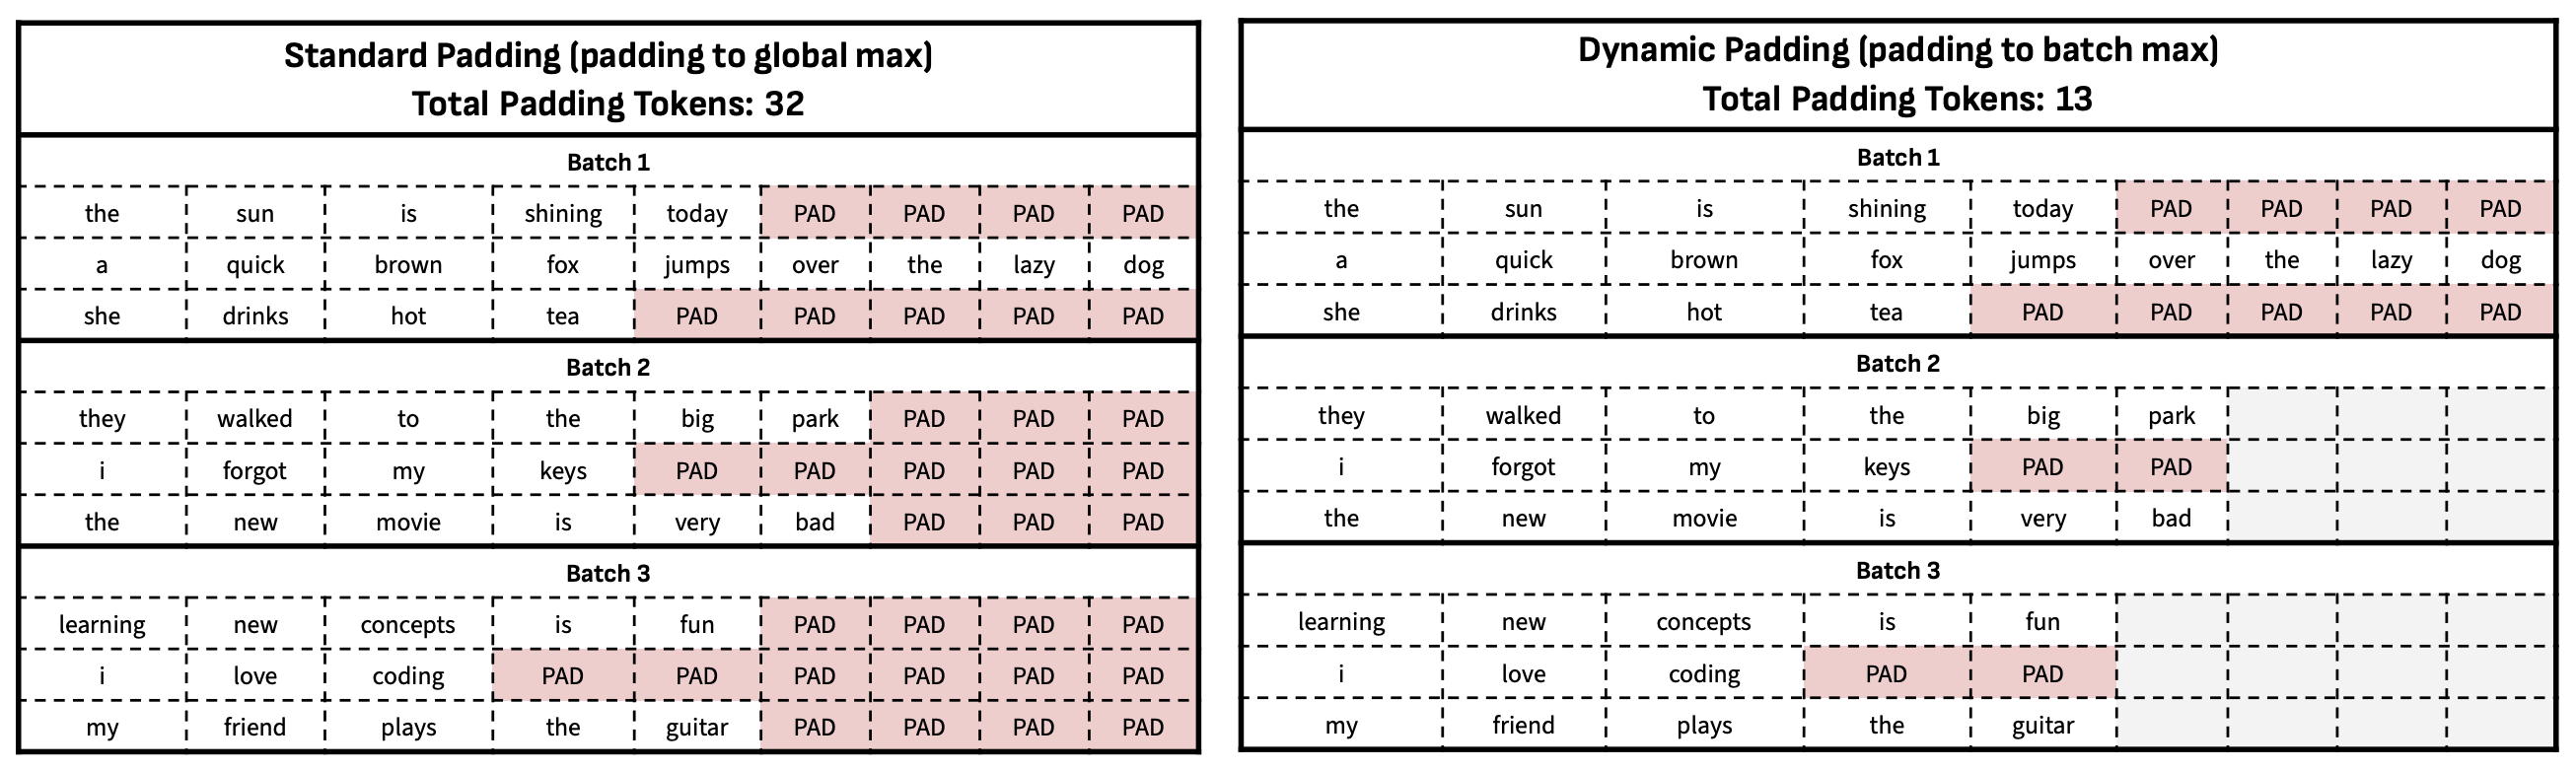

## Standard Padding

You pick one fixed max_length (e.g., 128 tokens) and apply it to every sequence in the entire dataset. Every sequence shorter than this length is padded, and every sequence longer is truncated. All resulting data samples have the exact same length.

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
  return tokenizer(example["sentence1"], example["sentence2"], padding="max_length", max_length=128)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["idx", "sentence1", "sentence2"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets = tokenized_datasets.with_format("torch")

In [ ]:
from torch.utils.data import DataLoader

# DataLoader are iterators over the Dataset data type - similar to using .items for dictionary loops
train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=16)

for step, batch in enumerate(train_dataloader):
  print(batch["input_ids"].shape) # fixed shape
  if step > 5:
    break

**Pros**

* **Simplicity:** It's very straightforward. You define the length once, and you're done.
* **Uniformity:** Every single tensor fed to the model will have the exact same shape (e.g., `[16, 128]`). This predictability can be useful for debugging.

**Cons**

* **Massive Inefficiency:** This is the biggest drawback. If your `max_length` is 512, but a batch contains sequences that are all around 30 tokens long, you are forcing the GPU to process **~94% padding tokens**. This wastes a significant amount of computation and memory, slowing down training.
* **Potential Information Loss:** If you choose a `max_length` that is too small, you will permanently truncate data from longer sequences before training even begins.

## Dynamic Padding

The padding length is determined dynamically for each batch. When creating a batch, you find the longest sequence within that specific batch and pad all other sequences in the batch to match its length. This means different batches will have different sequence lengths. This is typically handled by a DataCollator in the Hugging Face ecosystem.

It's achieved by leaving the padding argument out of the `.map()` call and using a `DataCollatorWithPadding` in your `DataLoader`.


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
  return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["idx", "sentence1", "sentence2"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets = tokenized_datasets.with_format("torch")

In [ ]:
print(tokenized_datasets.column_names)

In [ ]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)

train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=16, collate_fn=data_collator)

In [ ]:
for step, batch in enumerate(train_dataloader):
  print(batch["input_ids"].shape) # fixed shape
  if step > 5:
    break

**Pros**

* **High Efficiency:** This is the primary advantage. By creating batches that are as compact as possible, you drastically reduce the number of padding tokens. This **speeds up training** and **lowers memory usage**, sometimes by a large margin.
* **No Unnecessary Computation:** The model only processes the information that's actually there, plus the minimum required padding for that specific batch.

**Cons**

* **Variable Shapes:** The input tensor shape will change with every batch (e.g., one batch is `[16, 92]`, the next is `[16, 115]`). Modern deep learning frameworks like PyTorch and TensorFlow handle this seamlessly, but it's a point to be aware of.
* **Slightly More Complex Setup:** It's not just a single argument. You need to know to omit padding during the mapping phase and then add a `DataCollator` object when creating your `DataLoader`.





**Summary: Which Should You Use?**

| Feature | Standard Padding | Dynamic Padding |
| :--- | :--- | :--- |
| **Primary Goal** | Simplicity, compatibility | **Training efficiency** |
| **Performance** | Slower, more memory | **Faster, less memory** |
| **Implementation** | Simpler (one argument) | Requires a `DataCollator` |
| **Best For...** | Exporting models to specific environments, debugging | **Almost all training and evaluation tasks** |

**Recommendation:** For training models, **always prefer dynamic padding**. The performance gains are significant. Use standard padding only if you have a specific deployment requirement for fixed-size inputs.

# How to create your own Dataset

In [ ]:
from datasets import Dataset, Features, Image, Value
import pandas as pd

# Text Dataset
text_data = {
    "text": ["Hello world", "Hugging Face is great", "Machine learning is fun"],
    "label": [1, 1, 0]
}
text_dataset = Dataset.from_dict(text_data)
print("Text Dataset:", text_dataset)

# Image Dataset
# Assuming you have images in a folder; here we define the structure
# Note: To run this, you'd need actual image files at these paths
image_data = {
    "image": ["path/to/image1.jpg", "path/to/image2.png"],
    "label": [0, 1]
}
# Define features to tell the library the 'image' column contains images
features = Features({"image": Image(), "label": Value("int64")})
image_dataset = Dataset.from_dict(image_data, features=features)

# PDF (Text Extraction) Dataset
# To handle PDFs, you typically use a library like 'pypdf' or 'pdfplumber'
# !pip install pypdf

# Example of how you would structure the extracted content:
pdf_data = {
    "pdf_name": ["report.pdf"],
    "content": ["This is the extracted text from the PDF..."],
    "metadata": ["Author: John Doe"]
}
pdf_dataset = Dataset.from_dict(pdf_data)

display(text_dataset[0])